<a href="https://colab.research.google.com/github/renearenas-bit/LAB1/blob/main/content/LAB%2005.02%20-%20MODEL%20EVALUATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LAB 05.02 - Model evaluation

<a target="_blank" href="https://colab.research.google.com/github/rramosp/ai4eng.v1/blob/main/content/LAB%2005.02%20-%20MODEL%20EVALUATION.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()


replicating local resources


In [2]:
from local.lib.rlxmoocapi import submit, session
session.LoginSequence(endpoint=init.endpoint, course_id=init.course_id, lab_id="L05.02", varname="student");

logging in as rene.arenas@udea.edu.co... please wait

-------------
using course session ai4eng.v1.udea.r4::2026.1
success!! you are logged in
-------------


## Task 1: Partition randomly `numpy` arrays

observe we can select specific rows and/or columns on a numpy array

In [3]:
import numpy as np

x = np.random.randint(100, size=(20,5))
x[:,0] = range(len(x))
x[0,:] = range(x.shape[1])
x

array([[ 0,  1,  2,  3,  4],
       [ 1, 83, 47, 97, 39],
       [ 2, 90, 44,  5,  0],
       [ 3, 35, 29, 96, 17],
       [ 4, 39, 32, 92, 33],
       [ 5, 91,  9,  8, 63],
       [ 6, 63, 72, 55, 21],
       [ 7, 80, 18, 42, 66],
       [ 8, 29, 55, 82, 73],
       [ 9, 35, 91, 71,  8],
       [10, 87, 66, 13, 25],
       [11, 77, 27, 38, 80],
       [12, 65, 89, 79, 28],
       [13, 14, 49, 65,  5],
       [14, 33, 78,  8, 66],
       [15, 22, 67, 46, 17],
       [16, 62, 57, 88, 68],
       [17, 80,  8, 69,  1],
       [18, 19,  8, 32, 68],
       [19, 56, 94, 38, 38]])

In [4]:
ridxs = np.r_[2,4,5]
x[ridxs]

array([[ 2, 90, 44,  5,  0],
       [ 4, 39, 32, 92, 33],
       [ 5, 91,  9,  8, 63]])

In [5]:
cidxs = np.r_[1,3]
x[:,cidxs]

array([[ 1,  3],
       [83, 97],
       [90,  5],
       [35, 96],
       [39, 92],
       [91,  8],
       [63, 55],
       [80, 42],
       [29, 82],
       [35, 71],
       [87, 13],
       [77, 38],
       [65, 79],
       [14, 65],
       [33,  8],
       [22, 46],
       [62, 88],
       [80, 69],
       [19, 32],
       [56, 38]])

In [6]:
x[ridxs][:, cidxs]

array([[90,  5],
       [39, 92],
       [91,  8]])

and the dimensions of the array are accessible through `len` and `shape`

In [7]:
len(x), x.shape

(20, (20, 5))

observe also how we can partition it

In [8]:
x[:3]

array([[ 0,  1,  2,  3,  4],
       [ 1, 83, 47, 97, 39],
       [ 2, 90, 44,  5,  0]])

In [9]:
x[3:]

array([[ 3, 35, 29, 96, 17],
       [ 4, 39, 32, 92, 33],
       [ 5, 91,  9,  8, 63],
       [ 6, 63, 72, 55, 21],
       [ 7, 80, 18, 42, 66],
       [ 8, 29, 55, 82, 73],
       [ 9, 35, 91, 71,  8],
       [10, 87, 66, 13, 25],
       [11, 77, 27, 38, 80],
       [12, 65, 89, 79, 28],
       [13, 14, 49, 65,  5],
       [14, 33, 78,  8, 66],
       [15, 22, 67, 46, 17],
       [16, 62, 57, 88, 68],
       [17, 80,  8, 69,  1],
       [18, 19,  8, 32, 68],
       [19, 56, 94, 38, 38]])

we can do the same thing with vectors

In [10]:
v = np.arange(100,120)
v

array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119])

In [11]:
v[:5], v[5:]

(array([100, 101, 102, 103, 104]),
 array([105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
        118, 119]))

finally, observe how we can create a random permutation of a specific vector

In [12]:
np.random.permutation(v)

array([108, 118, 104, 114, 113, 102, 100, 112, 117, 101, 111, 115, 103,
       119, 106, 110, 109, 105, 107, 116])

or the first natural numbers

In [13]:
p = np.random.permutation(20)
p

array([ 2,  8,  0, 14, 19, 15,  4, 10, 13, 18,  3, 17,  9, 11,  5,  1, 12,
        6,  7, 16])

how do you interpret this?

In [14]:
v[p[5:]]

array([115, 104, 110, 113, 118, 103, 117, 109, 111, 105, 101, 112, 106,
       107, 116])

In [15]:
x[p[:5]]

array([[ 2, 90, 44,  5,  0],
       [ 8, 29, 55, 82, 73],
       [ 0,  1,  2,  3,  4],
       [14, 33, 78,  8, 66],
       [19, 56, 94, 38, 38]])

### assignment

in this task you will have to complete the function  `split_data` below so that:

- it accepts two arguments `X` and `y`, either of which can be any numpy array (1D, 2D, etc.) of the **same** size $n$ (observe the  `assert` statement), and a `pct`
- creates a random permutation of the natural number from $0$ to $n-1$
- partitions the permutations so that the first partition contains the first `n1_elements` $=$ `int(n * pct)` numbers, and the second partition the rest
- interpret the permutation partitions components as indexes to `X` and `y` so that they are partitioned into `X1`, `X2` and `y1`, `y2` respectively

note that **indexes to array** must be of type `int`. do the following to convert a float to int

In [16]:
a,b = 10,.3
c = a*b
print (c)
c = int(c)
print(c)

3.0
3


SyntaxError: invalid syntax (2726586825.py, line 6)

In [18]:
import numpy as np

def split_data(X, y, pct):
    assert len(X) == len(y), "X and y must have the same length"
    assert pct > 0 and pct < 1, "pct must be in the (0,1) interval"

    n = len(X)
    permutation = np.random.permutation(n)

    n1_elements = int(n * pct)

    permutation_partition_1 = permutation[:n1_elements]
    permutation_partition_2 = permutation[n1_elements:]

    X1 = X[permutation_partition_1]
    X2 = X[permutation_partition_2]

    y1 = y[permutation_partition_1]
    y2 = y[permutation_partition_2]

    return X1, X2, y1, y2


check your solution manually with the following code

In [19]:
XX = np.random.randint(100, size=(20,8))
yy = np.arange(100,100+len(XX))
XX[:,0] = range(len(XX))
XX[0,:] = range(XX.shape[1])
print (XX)
print (yy)

[[ 0  1  2  3  4  5  6  7]
 [ 1 23 86 12 15 64 97 28]
 [ 2 27 68 89 90 55 69 84]
 [ 3 91 62 66 85 86 21 51]
 [ 4 26 92  3 98 57 94 37]
 [ 5 84 51 87  2 51 75 80]
 [ 6 35 85 81  8 19 40 75]
 [ 7 52  1 35 69 71 62 27]
 [ 8 68 30 83 55 74 88 17]
 [ 9 42 40 24 95 89 64  6]
 [10 60 35 79 56  9 13 12]
 [11 41 27 39 53 40 28 51]
 [12 18 75 44 59 58 32 54]
 [13 11 44 99 55 65 30 31]
 [14 16 64 53 23 91 92 90]
 [15 14 56 17 21 60 47 10]
 [16 11 90 49 35 18 30 23]
 [17 96  5 19 26 22 30  2]
 [18 14 40 70 52 86  2 77]
 [19 17 65 37 33 33 39 92]]
[100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119]


In [20]:
Xtr, Xts, ytr, yts = split_data(XX, yy, pct=.7)

In [21]:
# check partition ok
np.sum(XX), np.sum(Xtr) + np.sum(Xts), np.sum(yy), np.sum(ytr)+np.sum(yts)

(np.int64(6744), np.int64(6744), np.int64(2190), np.int64(2190))

In [22]:
print (Xtr, "\n--")
print (Xts, "\n--")
print (ytr, "\n--")
print (yts, "\n--")

[[ 8 68 30 83 55 74 88 17]
 [11 41 27 39 53 40 28 51]
 [18 14 40 70 52 86  2 77]
 [ 4 26 92  3 98 57 94 37]
 [ 2 27 68 89 90 55 69 84]
 [ 1 23 86 12 15 64 97 28]
 [15 14 56 17 21 60 47 10]
 [14 16 64 53 23 91 92 90]
 [ 9 42 40 24 95 89 64  6]
 [12 18 75 44 59 58 32 54]
 [10 60 35 79 56  9 13 12]
 [16 11 90 49 35 18 30 23]
 [ 3 91 62 66 85 86 21 51]
 [17 96  5 19 26 22 30  2]] 
--
[[ 6 35 85 81  8 19 40 75]
 [ 5 84 51 87  2 51 75 80]
 [ 0  1  2  3  4  5  6  7]
 [19 17 65 37 33 33 39 92]
 [13 11 44 99 55 65 30 31]
 [ 7 52  1 35 69 71 62 27]] 
--
[108 111 118 104 102 101 115 114 109 112 110 116 103 117] 
--
[106 105 100 119 113 107] 
--


In [23]:
Xts

array([[ 6, 35, 85, 81,  8, 19, 40, 75],
       [ 5, 84, 51, 87,  2, 51, 75, 80],
       [ 0,  1,  2,  3,  4,  5,  6,  7],
       [19, 17, 65, 37, 33, 33, 39, 92],
       [13, 11, 44, 99, 55, 65, 30, 31],
       [ 7, 52,  1, 35, 69, 71, 62, 27]])

**submit your code**

In [24]:
student.submit_task(globals(), task_id="task_01");


## Task 2: Fit a model and make predictions

observe how we create new data from synthetic datasets available in `sklearn`

In [25]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from local.lib import mlutils
%matplotlib inline

/content/local/lib/mlutils.py:445: SyntaxWarning: invalid escape sequence '\m'
  time_str = "fit time  (TRAIN)    %.2f $\mu$secs"%(fitting_time*1000)


In [26]:
X, y = make_moons(200, noise=0.2)
X.shape, y.shape

((200, 2), (200,))

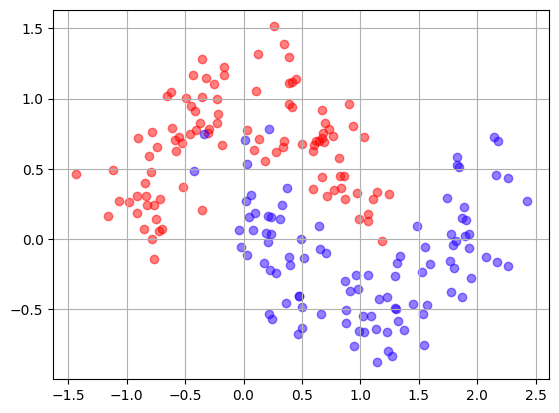

In [27]:
mlutils.plot_2Ddata(X,y); plt.grid();

observe also how we create an algorithm instance and fit a model

(np.float64(0.511175), np.float64(0.488825))

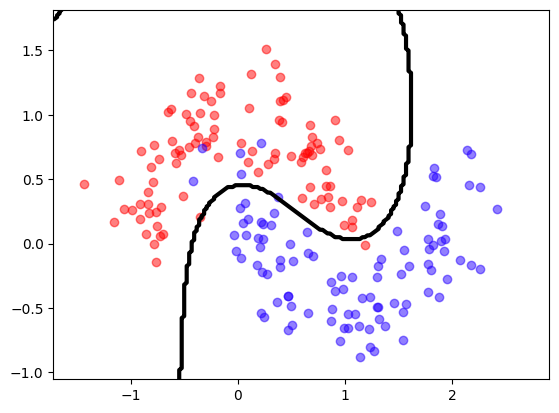

In [28]:
from sklearn.svm import SVC
estimator = SVC(gamma=1)
estimator.fit(X,y)
mlutils.plot_2Ddata_with_boundary(estimator.predict, X, y)

and how we make predictions

In [29]:
preds = estimator.predict(X)
print (preds.shape)
preds

(200,)


array([0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       0, 0])

in this task you have to complete the following function so that:

- it makes two non-random partitions of `X` and `y`. One containing the first half of the data and one containing the second part. If the number of elements of `X` is odd, then the second half will contain one more element than the first half.
- it fits the model with the first part of the data
- it makes predictions on the second half of the data
- returns the estimator fitted, and the predictions on the second half of the data.

In [30]:
def fit_and_predict(estimator, X, y):
    assert len(X) == len(y), "X and y must have the same length"

    n = len(X)
    mid = n // 2

    X1 = X[:mid]
    y1 = y[:mid]

    X2 = X[mid:]

    estimator.fit(X1, y1)
    predictions = estimator.predict(X2)

    return estimator, predictions


check your code. your predictions should be similar to

    preds
    >> array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0])

In [31]:
X = np.array([[ 0.74799424, -0.5867667 ],
       [-0.64457753,  1.25127894],
       [ 0.53682593,  0.10931563],
       [-0.88825294, -0.06987509],
       [ 0.99612638, -0.52295157],
       [ 1.20586692,  0.01930477],
       [-0.19368482,  0.65121567],
       [ 0.1973759 ,  0.82250723],
       [ 0.94859234, -0.5457241 ],
       [ 1.87967948, -0.22740261],
       [ 0.58766146,  0.3982837 ],
       [ 0.27731571,  1.14369568],
       [-0.67421956,  0.12785382],
       [ 0.56957459,  1.05330376],
       [ 1.52435938, -0.29864338],
       [-0.15973608,  0.21790711],
       [ 1.59037406, -0.56875485],
       [ 0.43257507, -0.48900315],
       [ 1.09440413, -0.73789029],
       [-0.32940869,  0.74671384]])
y = np.array([1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0])
X.shape, y.shape

((20, 2), (20,))

In [32]:
from sklearn.linear_model import LogisticRegression
estimator = LogisticRegression()
estimator, preds = fit_and_predict(estimator, X, y)
preds

array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0])

**submit your code**

In [33]:
student.submit_task(globals(), task_id="task_02");


## Task 3: Select data with indices

Observe how we can create a vector or matrix of `True/False` (boolean) by applying a condition to any matrix or vector

In [34]:
import numpy as np
y = np.random.randint(10, size=15)
print (y)

[0 4 0 5 4 4 9 3 4 8 3 6 1 4 9]


In [35]:
y_less_than_5 = y<5
print (y_less_than_5)

[ True  True  True False  True  True False  True  True False  True False
  True  True False]


and how we can select elements of a vector using a boolean vector of the same length

In [36]:
y[y_less_than_5]

array([0, 4, 0, 4, 4, 3, 4, 3, 1, 4])

In [37]:
y[y<5]

array([0, 4, 0, 4, 4, 3, 4, 3, 1, 4])

python doesn't really care how you construct the vector of booleans to index any other vector or array

In [38]:
v = np.random.randint(20, size=15)
v

array([12,  8, 14,  8, 17, 13, 11, 18, 17,  3,  4,  8,  2, 17, 12])

In [39]:
v[y<5]

array([12,  8, 14, 17, 13, 18, 17,  4,  2, 17])

in this task you will complete the function `select_per_class` such that:

- receives an array of data `X` and a vector of labels `y`, of the same length
- the labels `y` are binary, they can only have values `0` or `1`
- makes two partitions of `X`, one corresponding to the places where y is 0, and another where y is 1
- returns the two partitions

For instance, for the following X and y

    X = np.array([[8, 8, 5, 2, 0, 0],
                  [4, 4, 8, 1, 3, 7],
                  [4, 5, 3, 6, 9, 6],
                  [0, 3, 5, 3, 5, 3],
                  [0, 7, 2, 7, 1, 7],
                  [5, 7, 7, 1, 8, 5],
                  [2, 5, 7, 3, 8, 0],
                  [7, 2, 5, 9, 8, 7],
                  [1, 6, 6, 1, 6, 0],
                  [0, 7, 6, 5, 3, 4]])

    y = np.array([0, 0, 0, 0, 1, 1, 0, 0, 1, 1])

your function must return the following two matrices:

    [[8 8 5 2 0 0]
     [4 4 8 1 3 7]
     [4 5 3 6 9 6]
     [0 3 5 3 5 3]
     [2 5 7 3 8 0]
     [7 2 5 9 8 7]]
     
    [[0 7 2 7 1 7]
     [5 7 7 1 8 5]
     [1 6 6 1 6 0]
     [0 7 6 5 3 4]]


In [40]:
def select_per_class(X, y):
    X1 = X[y == 0]
    X2 = X[y == 1]
    return X1, X2

check manually your code

In [41]:
X = np.array([[8, 8, 5, 2, 0, 0],
              [4, 4, 8, 1, 3, 7],
              [4, 5, 3, 6, 9, 6],
              [0, 3, 5, 3, 5, 3],
              [0, 7, 2, 7, 1, 7],
              [5, 7, 7, 1, 8, 5],
              [2, 5, 7, 3, 8, 0],
              [7, 2, 5, 9, 8, 7],
              [1, 6, 6, 1, 6, 0],
              [0, 7, 6, 5, 3, 4]])

y = np.array([0, 0, 0, 0, 1, 1, 0, 0, 1, 1])

In [42]:
a,b = select_per_class(X, y)
print (a)
print (b)

[[8 8 5 2 0 0]
 [4 4 8 1 3 7]
 [4 5 3 6 9 6]
 [0 3 5 3 5 3]
 [2 5 7 3 8 0]
 [7 2 5 9 8 7]]
[[0 7 2 7 1 7]
 [5 7 7 1 8 5]
 [1 6 6 1 6 0]
 [0 7 6 5 3 4]]


**submit your code**

In [43]:
student.submit_task(globals(), task_id="task_03");


## Task 4: Measure accuracy

complete the following function such that:

- it receives to binary vectors (composed of 0's and 1's) of the same length
- returns the percentage of elements that are the same in both vectors

recall that

- if `a` and `b` are vectors of the same length a==b   returns a vector of booleans in which positions in True signal that elements in those position are the same
- if `k` is a vector of booleans, `sum(k)` returns the number of `True` elements.


for the following two vectors you should get 0.375

    a = np.array([1,0,0,0,1,1,0,0])
    b = np.array([1,1,1,1,0,1,0,1])
    accuracy(a, b)
    >>> 0.375


In [44]:
def accuracy(y_true, y_pred):
    result = np.mean(y_true == y_pred)
    return result

In [45]:
a = np.array([1,0,0,0,1,1,0,0])
b = np.array([1,1,1,1,0,1,0,1])
accuracy(a,b)

np.float64(0.375)

**submit your code**

In [46]:
student.submit_task(globals(), task_id="task_04");


## Task 5: Random split, fit and predict

complete the following function so that:

- fits the estimator with a random sample of size `train_pct` of the data `X` and binary labels `y`. You can use the `split_data` function developed previously
- makes predictions on the test part of the data
- measures accuracy of those predictions. you may use the function created previously
- returns the estimator fitted, the test part of `X` and `y`, and the accuracy measured


the execution below should return something with the following structure (the actual numbers will change)


    (LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                        intercept_scaling=1, l1_ratio=None, max_iter=100,
                        multi_class='warn', n_jobs=None, penalty='l2',
                        random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                        warm_start=False), array([[-0.76329684,  0.2572069 ],
            [ 1.02356829,  0.37629873],
            [ 0.32099415,  0.82244488],
            [ 1.08858315, -0.61299904],
            [ 0.58470767,  0.58510559],
            [ 1.60827644, -0.15477173],
            [ 1.53121784,  0.78121504],
            [-0.42734156,  0.87585237],
            [-0.36368682,  0.72152586],
            [ 1.05312619,  0.19835526]]), array([0, 0, 1, 1, 0, 1, 1, 0, 0, 0]), 0.6)

In [47]:

import numpy as np

def split_fit_predict(estimator, X, y, train_pct):

    def split_data(X, y, pct):
        n_samples = len(X)
        indices = np.arange(n_samples)
        np.random.shuffle(indices)
        split_point = int(n_samples * pct)
        train_idx = indices[:split_point]
        test_idx = indices[split_point:]
        X_train = X[train_idx]
        y_train = y[train_idx]
        X_test = X[test_idx]
        y_test = y[test_idx]
        return X_train, X_test, y_train, y_test

    def accuracy(y_true, y_pred):
        return np.mean(y_true == y_pred)

    Xtr, Xts, ytr, yts = split_data(X, y, train_pct)
    estimator.fit(Xtr, ytr)
    preds_ts = estimator.predict(Xts)

    return estimator, Xts, yts, accuracy(yts, preds_ts)



In [48]:
from sklearn.linear_model import LogisticRegression

X, y = make_moons(100, noise=0.2)
estimator = LogisticRegression(solver="lbfgs")
split_fit_predict(estimator, X, y, train_pct=0.9)


(LogisticRegression(),
 array([[ 1.42949395, -0.21922155],
        [ 0.80397193, -0.26943968],
        [ 1.41647528, -0.00451526],
        [ 2.20006847, -0.04814822],
        [ 1.04620259,  0.09801853],
        [ 1.83189253,  0.35349999],
        [ 0.44891331, -0.44098839],
        [ 1.36089034, -0.27335481],
        [ 0.41542886, -0.48665051],
        [ 0.63782208, -0.6277514 ]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 1]),
 np.float64(0.9))

**submit your code**

In [49]:
student.submit_task(globals(), task_id="task_05");
